# 08 - Outliers y casos especiales

Este notebook tiene como objetivo analizar con mayor profundidad los registros atípicos y casos especiales detectados durante la limpieza de datos.

En este análisis se revisan:

- Cantidades negativas.
- Cantidades iguales a cero.
- Ventas negativas.
- Ventas iguales a cero.
- Descuentos negativos.
- Descuentos mayores que la venta.
- Ventas netas negativas.
- Ventas netas iguales a cero.
- Precios unitarios extremos.
- Productos con comportamiento atípico.
- Días con ventas atípicas.
- Tickets con valores atípicos.
- Casos especiales por PDV y categoría.

El objetivo no es eliminar datos automáticamente, sino entender qué representan estos casos y definir criterios razonables para tratarlos en etapas posteriores.

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

OUTLIERS_FIGURES_DIR = FIGURES_DIR / "outliers"
CALIDAD_FIGURES_DIR = FIGURES_DIR / "calidad_datos"

PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"
TICKETS_FILE = PROCESSED_DIR / "tickets_eda.parquet"

OUTLIERS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CALIDAD_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo procesado:")
print(PROCESSED_FILE)

print("\n¿Existe el archivo?")
print(PROCESSED_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo procesado:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de base limpia
# ===============================

df = pd.read_parquet(PROCESSED_FILE)

df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

print("Base procesada cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Base procesada cargada correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [4]:
# ===============================
# Validación de columnas necesarias
# ===============================

columnas_necesarias = [
    "FECHA",
    "ANIO",
    "MES",
    "PDV",
    "Estrato",
    "CATEG",
    "PLU_SAP",
    "TICKET_ID",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "DESCUENTO_PCT",
    "PRECIO_UNITARIO_NETO",
    "PROMO_FLAG",
    "REGISTRO_ESPECIAL",
    "REGISTRO_VALIDO_BASICO"
]

faltantes = [col for col in columnas_necesarias if col not in df.columns]

if len(faltantes) == 0:
    print("Todas las columnas necesarias están disponibles.")
else:
    print("Faltan estas columnas:")
    print(faltantes)

Todas las columnas necesarias están disponibles.


In [5]:
# ===============================
# Resumen general de casos especiales
# ===============================

casos_especiales = pd.DataFrame({
    "caso": [
        "Registros totales",
        "Registros especiales",
        "Registros válidos básicos",
        "Fecha nula",
        "Cantidad nula",
        "Cantidad igual a cero",
        "Cantidad negativa",
        "Venta nula",
        "Venta igual a cero",
        "Venta negativa",
        "Descuento nulo",
        "Descuento igual a cero",
        "Descuento negativo",
        "Descuento mayor que venta",
        "Venta neta nula",
        "Venta neta igual a cero",
        "Venta neta negativa",
        "Precio unitario neto nulo",
        "Precio unitario neto negativo"
    ],
    "cantidad": [
        len(df),
        df["REGISTRO_ESPECIAL"].sum(),
        df["REGISTRO_VALIDO_BASICO"].sum(),
        df["FECHA"].isna().sum(),
        df["CANT"].isna().sum(),
        (df["CANT"] == 0).sum(),
        (df["CANT"] < 0).sum(),
        df["VENTA"].isna().sum(),
        (df["VENTA"] == 0).sum(),
        (df["VENTA"] < 0).sum(),
        df["DESCUENTO"].isna().sum(),
        (df["DESCUENTO"] == 0).sum(),
        (df["DESCUENTO"] < 0).sum(),
        (df["DESCUENTO"] > df["VENTA"]).sum(),
        df["VENTA_NETA"].isna().sum(),
        (df["VENTA_NETA"] == 0).sum(),
        (df["VENTA_NETA"] < 0).sum(),
        df["PRECIO_UNITARIO_NETO"].isna().sum(),
        (df["PRECIO_UNITARIO_NETO"] < 0).sum()
    ]
})

casos_especiales["porcentaje"] = casos_especiales["cantidad"] / len(df) * 100

casos_especiales

,caso,cantidad,porcentaje
0,Registros totales,409760,100.00
1,Registros especiales,13497,3.29
2,Registros válidos básicos,398537,97.26
3,Fecha nula,0,0.00
4,Cantidad nula,180,0.04
5,Cantidad igual a cero,2322,0.57
6,Cantidad negativa,133,0.03
7,Venta nula,0,0.00
8,Venta igual a cero,3470,0.85
9,Venta negativa,1763,0.43


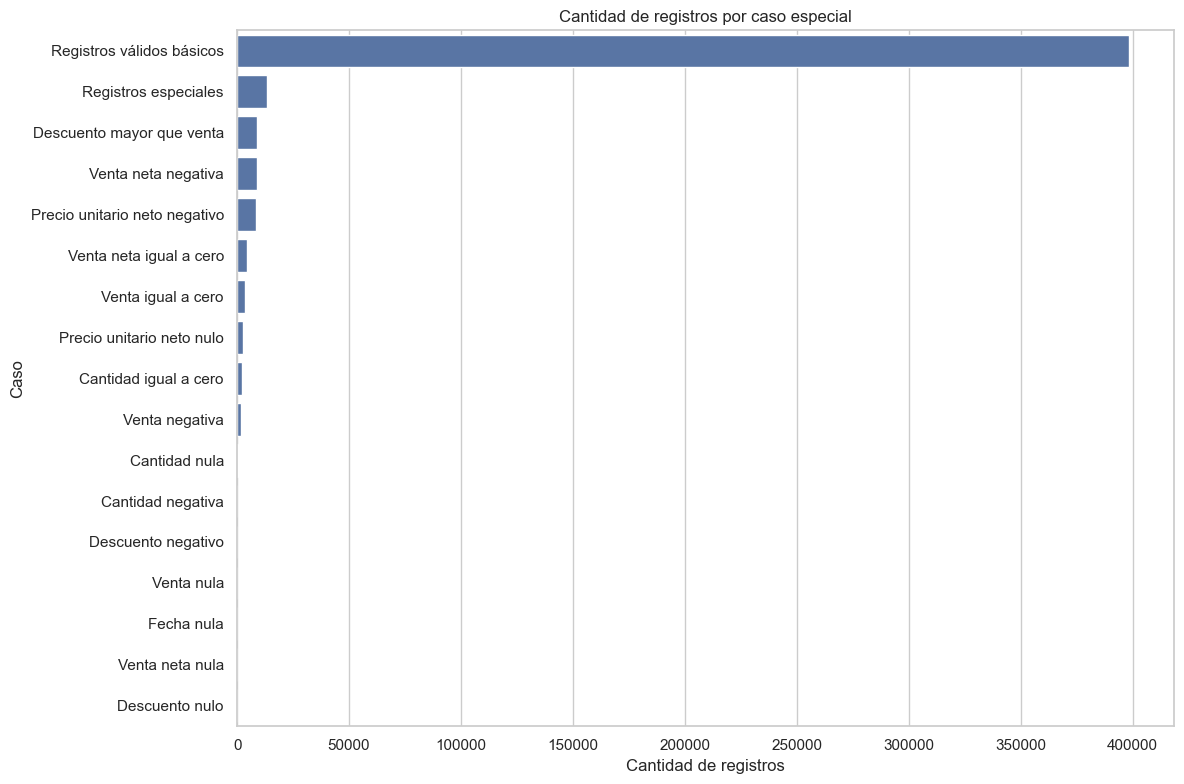

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\casos_especiales_general.png


In [6]:
# ===============================
# Gráfico de casos especiales
# ===============================

casos_plot = casos_especiales[
    ~casos_especiales["caso"].isin(["Registros totales", "Descuento igual a cero"])
].copy()

casos_plot = casos_plot.sort_values("cantidad", ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=casos_plot,
    y="caso",
    x="cantidad"
)

plt.title("Cantidad de registros por caso especial")
plt.xlabel("Cantidad de registros")
plt.ylabel("Caso")
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "casos_especiales_general.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [7]:
# ===============================
# Registros especiales
# ===============================

df_especiales = df[df["REGISTRO_ESPECIAL"]].copy()
df_validos = df[df["REGISTRO_VALIDO_BASICO"]].copy()

print(f"Registros especiales: {len(df_especiales):,}")
print(f"Registros válidos básicos: {len(df_validos):,}")
print(f"Porcentaje especiales: {len(df_especiales) / len(df) * 100:.2f}%")
print(f"Porcentaje válidos básicos: {len(df_validos) / len(df) * 100:.2f}%")

df_especiales.head()

Registros especiales: 13,497
Registros válidos básicos: 398,537
Porcentaje especiales: 3.29%
Porcentaje válidos básicos: 97.26%


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
87,1782,2023-01-01,1255,4,163377,57,04010,1345338,1.00,71.00,71.00,10,44927,163377,0.00,100.00,71.00,0.00,True,True,True,Oferta y descuento,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_57,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True
93,1903,2023-01-01,1255,4,163377,57,04010,1345337,1.00,71.00,71.00,10,44927,163377,0.00,100.00,71.00,0.00,True,True,True,Oferta y descuento,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_57,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True
123,2448,2023-01-01,980,4,0,106,04010,1036245,0.00,0.00,0.00,10,44927,0,0.00,NaN,NaN,NaN,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_106,False,False,True,False,False,True,False,False,True,False,False,False,True,False,True,False,True,False
195,4362,2023-01-01,1255,4,0,152,08061,1008762,0.00,0.00,0.00,11,44927,0,0.00,NaN,NaN,NaN,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_152,False,False,True,False,False,True,False,False,True,False,False,False,True,False,True,False,True,False
366,8554,2023-01-02,1255,4,163446,288,08042,1341191,1.00,178.00,416.00,11,44928,163446,-238.00,233.71,178.00,-238.00,True,True,True,Oferta y descuento,2023,1,2,0,Monday,1,1,False,False,False,1,Enero,Lunes,2023-01-02_1255_288,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,True,False


In [8]:
# ===============================
# Casos especiales por PDV
# ===============================

especiales_pdv = (
    df.groupby("PDV")
    .agg(
        filas=("NroReg", "count"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum"),
        cant_cero=("FLAG_CANT_CERO", "sum"),
        cant_negativa=("FLAG_CANT_NEGATIVA", "sum"),
        venta_cero=("FLAG_VENTA_CERO", "sum"),
        venta_negativa=("FLAG_VENTA_NEGATIVA", "sum"),
        descuento_negativo=("FLAG_DESCUENTO_NEGATIVO", "sum"),
        descuento_mayor_venta=("FLAG_DESCUENTO_MAYOR_VENTA", "sum"),
        venta_neta_cero=("FLAG_VENTA_NETA_CERO", "sum"),
        venta_neta_negativa=("FLAG_VENTA_NETA_NEGATIVA", "sum")
    )
    .reset_index()
)

especiales_pdv["registros_especiales_pct"] = (
    especiales_pdv["registros_especiales"] / especiales_pdv["filas"] * 100
)

especiales_pdv["registros_validos_basicos_pct"] = (
    especiales_pdv["registros_validos_basicos"] / especiales_pdv["filas"] * 100
)

especiales_pdv.sort_values("registros_especiales_pct", ascending=False)

,PDV,filas,registros_especiales,registros_validos_basicos,cant_cero,cant_negativa,venta_cero,venta_negativa,descuento_negativo,descuento_mayor_venta,venta_neta_cero,venta_neta_negativa,registros_especiales_pct,registros_validos_basicos_pct
2,980,75701,3278,72932,573,15,968,636,0,2209,1040,2209,4.33,96.34
0,1255,132627,4191,129092,767,63,1149,505,2,2688,1422,2688,3.16,97.33
1,1311,201432,6028,196513,982,55,1353,622,10,3902,2059,3902,2.99,97.56


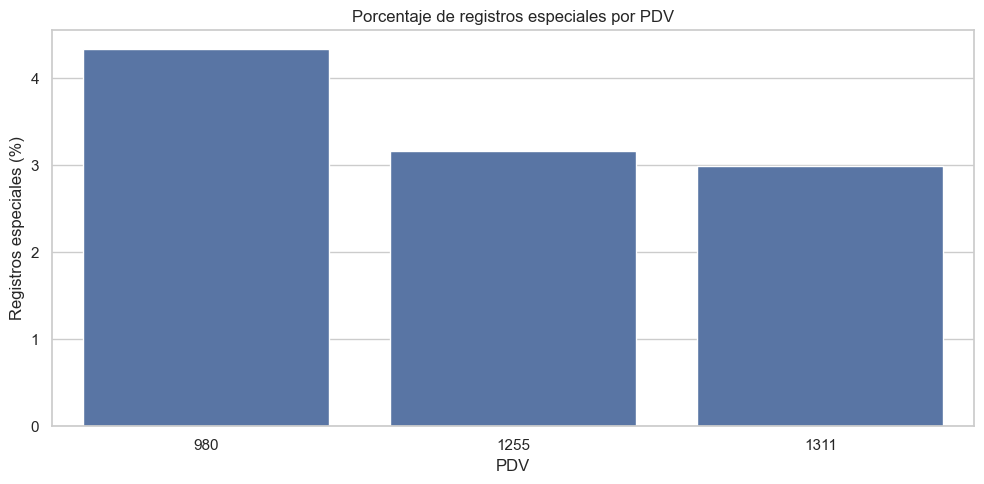

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\registros_especiales_por_pdv.png


In [9]:
# ===============================
# Gráfico registros especiales por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=especiales_pdv.sort_values("registros_especiales_pct", ascending=False),
    x="PDV",
    y="registros_especiales_pct"
)

plt.title("Porcentaje de registros especiales por PDV")
plt.xlabel("PDV")
plt.ylabel("Registros especiales (%)")
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "registros_especiales_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [10]:
# ===============================
# Casos especiales por categoría
# ===============================

especiales_categoria = (
    df.groupby("CATEG")
    .agg(
        filas=("NroReg", "count"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum"),
        cant_cero=("FLAG_CANT_CERO", "sum"),
        cant_negativa=("FLAG_CANT_NEGATIVA", "sum"),
        venta_cero=("FLAG_VENTA_CERO", "sum"),
        venta_negativa=("FLAG_VENTA_NEGATIVA", "sum"),
        descuento_negativo=("FLAG_DESCUENTO_NEGATIVO", "sum"),
        descuento_mayor_venta=("FLAG_DESCUENTO_MAYOR_VENTA", "sum"),
        venta_neta_cero=("FLAG_VENTA_NETA_CERO", "sum"),
        venta_neta_negativa=("FLAG_VENTA_NETA_NEGATIVA", "sum"),
        venta_neta=("VENTA_NETA", "sum")
    )
    .reset_index()
)

especiales_categoria["registros_especiales_pct"] = (
    especiales_categoria["registros_especiales"] / especiales_categoria["filas"] * 100
)

especiales_categoria["registros_validos_basicos_pct"] = (
    especiales_categoria["registros_validos_basicos"] / especiales_categoria["filas"] * 100
)

especiales_categoria.sort_values("registros_especiales_pct", ascending=False)

,CATEG,filas,registros_especiales,registros_validos_basicos,cant_cero,cant_negativa,venta_cero,venta_negativa,descuento_negativo,descuento_mayor_venta,venta_neta_cero,venta_neta_negativa,venta_neta,registros_especiales_pct,registros_validos_basicos_pct
0,04010,158659,9111,151519,1213,11,2222,1254,0,5988,3123,5988,"53,779,358.00",5.74,95.50
6,08067,876,47,829,6,40,6,40,0,41,6,41,"698,213.00",5.37,94.63
5,08062,10997,528,10491,94,4,104,56,2,354,116,354,"5,445,517.00",4.80,95.40
3,08042,52788,902,52005,191,20,234,73,3,576,305,576,"27,116,982.00",1.71,98.52
2,08029,132505,2167,130491,622,38,693,271,3,1325,769,1325,"25,966,820.00",1.64,98.48
4,08061,53538,741,52806,195,20,210,69,4,515,201,515,"10,153,870.00",1.38,98.63
1,04019,397,1,396,1,0,1,0,0,0,1,0,"31,602.00",0.25,99.75


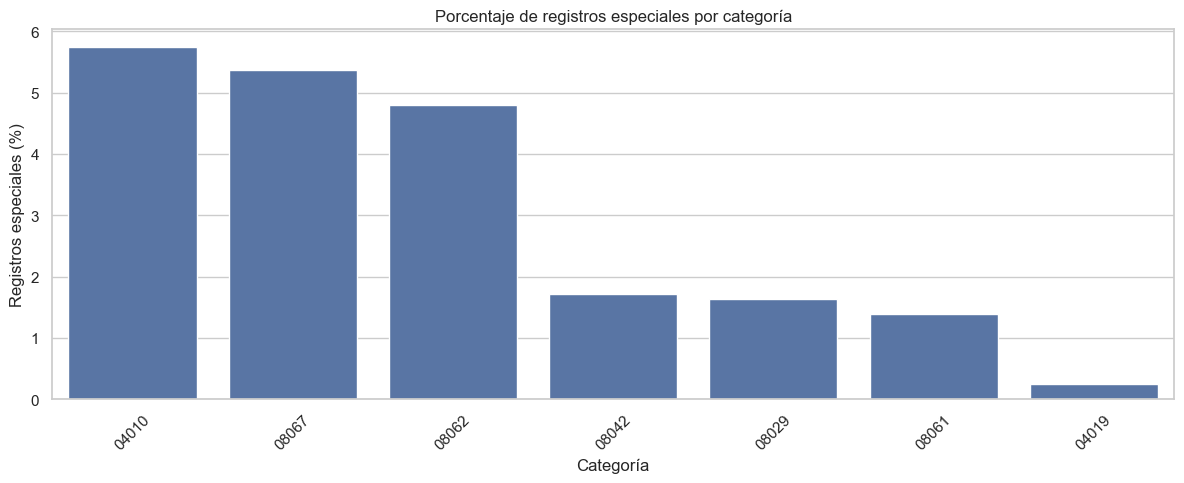

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\registros_especiales_por_categoria.png


In [11]:
# ===============================
# Gráfico registros especiales por categoría
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=especiales_categoria.sort_values("registros_especiales_pct", ascending=False),
    x="CATEG",
    y="registros_especiales_pct"
)

plt.title("Porcentaje de registros especiales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Registros especiales (%)")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "registros_especiales_por_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [12]:
# ===============================
# Función de detección de outliers por IQR
# ===============================

def detectar_outliers_iqr(data, columna, factor=1.5):
    """
    Detecta outliers usando el método IQR.
    Retorna límites y una serie booleana.
    """
    q1 = data[columna].quantile(0.25)
    q3 = data[columna].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - factor * iqr
    limite_superior = q3 + factor * iqr
    
    mask_outlier = (data[columna] < limite_inferior) | (data[columna] > limite_superior)
    
    return {
        "columna": columna,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "outliers": mask_outlier,
        "n_outliers": mask_outlier.sum(),
        "pct_outliers": mask_outlier.mean() * 100
    }

In [13]:
# ===============================
# Outliers por variable numérica
# ===============================

variables_outliers = [
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "DESCUENTO_PCT",
    "PRECIO_UNITARIO_NETO"
]

resumen_outliers_linea = []

for col in variables_outliers:
    temp = df[df[col].notna()].copy()
    resultado = detectar_outliers_iqr(temp, col)
    
    resumen_outliers_linea.append({
        "variable": col,
        "q1": resultado["q1"],
        "q3": resultado["q3"],
        "iqr": resultado["iqr"],
        "limite_inferior": resultado["limite_inferior"],
        "limite_superior": resultado["limite_superior"],
        "outliers": resultado["n_outliers"],
        "outliers_pct": resultado["pct_outliers"]
    })

resumen_outliers_linea = pd.DataFrame(resumen_outliers_linea)

resumen_outliers_linea

,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers,outliers_pct
0,CANT,1.00,1.00,0.00,1.00,1.00,97823,23.88
1,VENTA,83.00,398.00,315.00,-389.50,870.50,32875,8.02
2,DESCUENTO,0.00,8.00,8.00,-12.00,20.00,86453,21.10
3,VENTA_NETA,75.00,342.00,267.00,-325.50,742.50,38858,9.48
4,DESCUENTO_PCT,0.00,10.00,10.00,-15.00,25.00,36946,9.13
5,PRECIO_UNITARIO_NETO,88.00,385.00,297.00,-357.50,830.50,32584,8.00


In [14]:
# ===============================
# Crear banderas de outliers de línea
# ===============================

for col in variables_outliers:
    temp = df[df[col].notna()].copy()
    resultado = detectar_outliers_iqr(temp, col)
    
    flag_name = f"OUTLIER_{col}_IQR"
    df[flag_name] = False
    df.loc[temp.index, flag_name] = resultado["outliers"]

flags_outliers_linea = [f"OUTLIER_{col}_IQR" for col in variables_outliers]

df["OUTLIER_LINEA_GENERAL"] = df[flags_outliers_linea].any(axis=1)

print(f"Registros con al menos un outlier de línea: {df['OUTLIER_LINEA_GENERAL'].sum():,}")
print(f"Porcentaje: {df['OUTLIER_LINEA_GENERAL'].mean() * 100:.2f}%")

df[["CANT", "VENTA", "DESCUENTO", "VENTA_NETA", "DESCUENTO_PCT", "PRECIO_UNITARIO_NETO"] + flags_outliers_linea].head()

Registros con al menos un outlier de línea: 199,851
Porcentaje: 48.77%


,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_NETO,OUTLIER_CANT_IQR,OUTLIER_VENTA_IQR,OUTLIER_DESCUENTO_IQR,OUTLIER_VENTA_NETA_IQR,OUTLIER_DESCUENTO_PCT_IQR,OUTLIER_PRECIO_UNITARIO_NETO_IQR
0,3.00,298.00,0.00,298.00,0.00,99.33,True,False,False,False,False,False
1,1.00,115.00,0.00,115.00,0.00,115.00,False,False,False,False,False,False
2,3.00,448.00,0.00,448.00,0.00,149.33,True,False,False,False,False,False
3,1.00,82.00,0.00,82.00,0.00,82.00,False,False,False,False,False,False
4,4.00,519.00,0.00,519.00,0.00,129.75,True,False,False,False,False,False


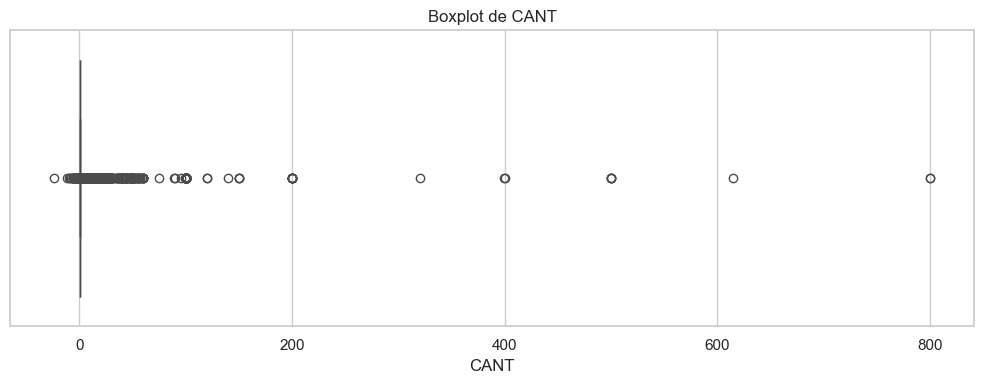

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_cant.png


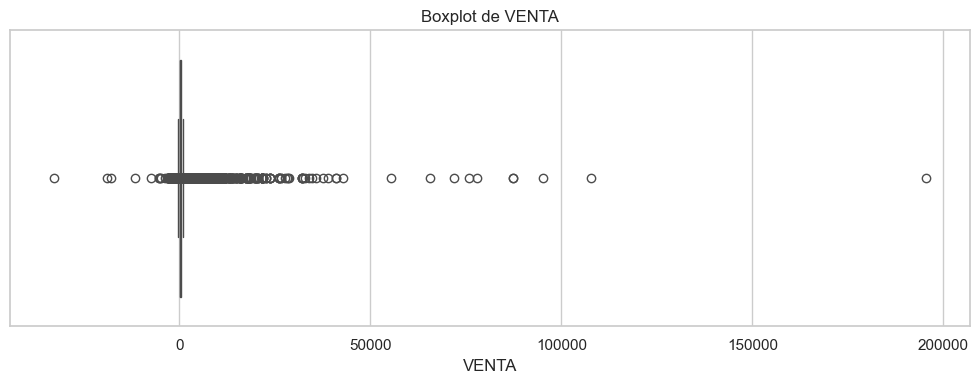

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_venta.png


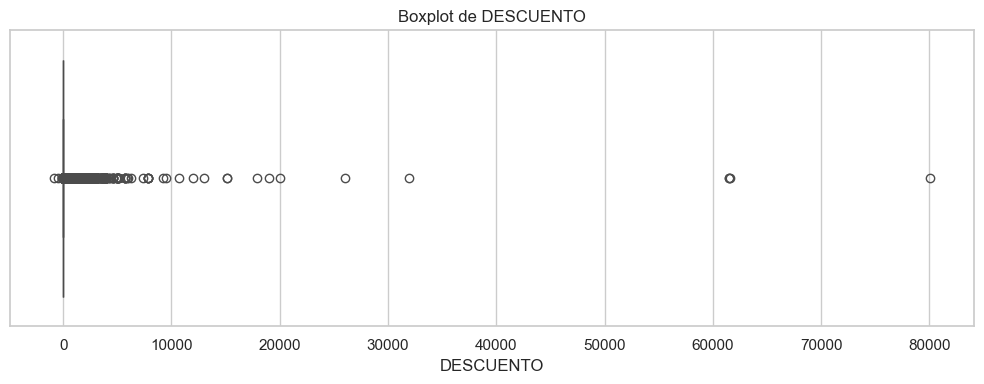

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_descuento.png


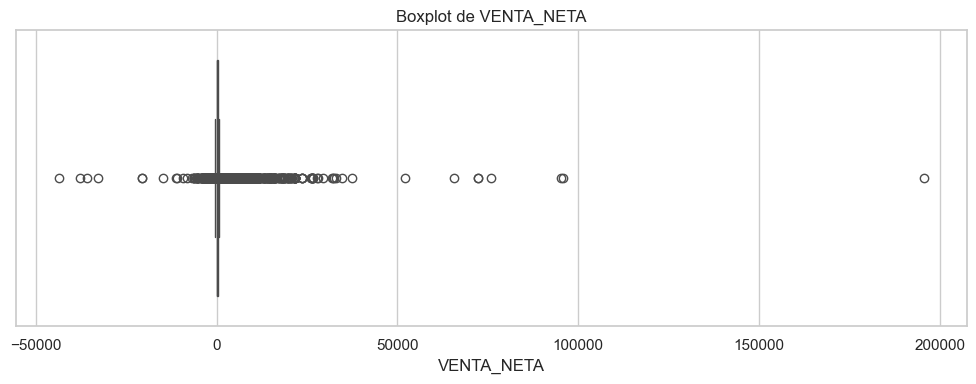

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_venta_neta.png


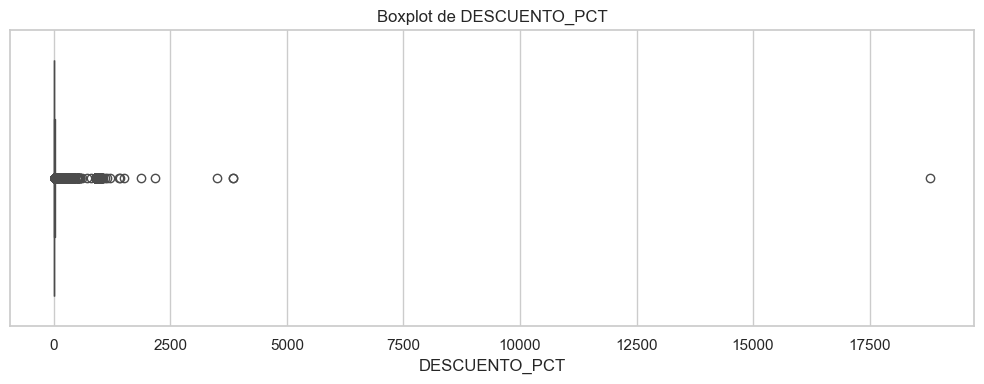

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_descuento_pct.png


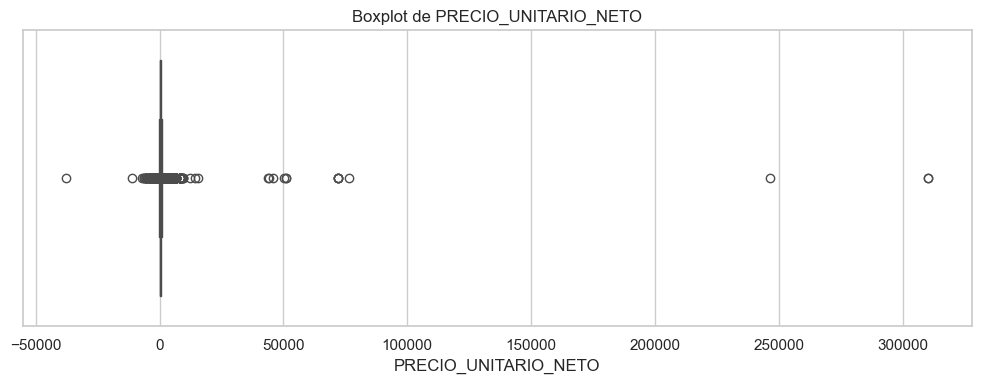

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_precio_unitario_neto.png


In [15]:
# ===============================
# Boxplots de variables numéricas
# ===============================

for col in variables_outliers:
    temp = df[df[col].notna()].copy()
    
    plt.figure(figsize=(10, 4))
    
    sns.boxplot(
        data=temp,
        x=col
    )
    
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    
    output_fig = OUTLIERS_FIGURES_DIR / f"boxplot_{col.lower()}.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print(f"Figura guardada en: {output_fig}")

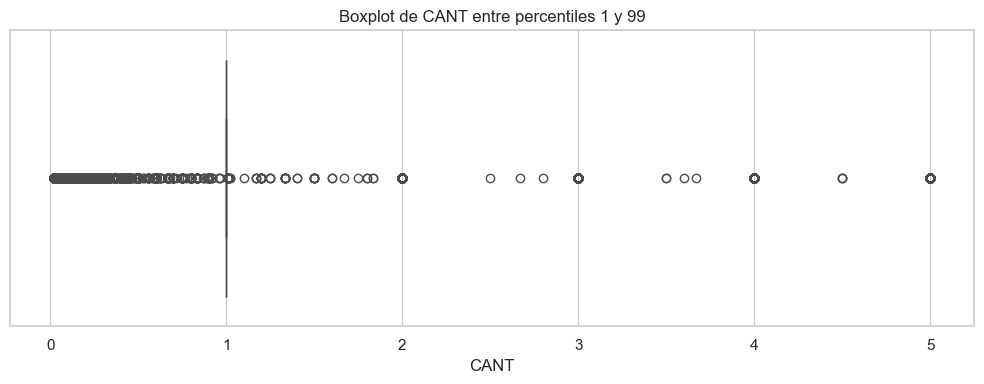

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_cant_p01_p99.png


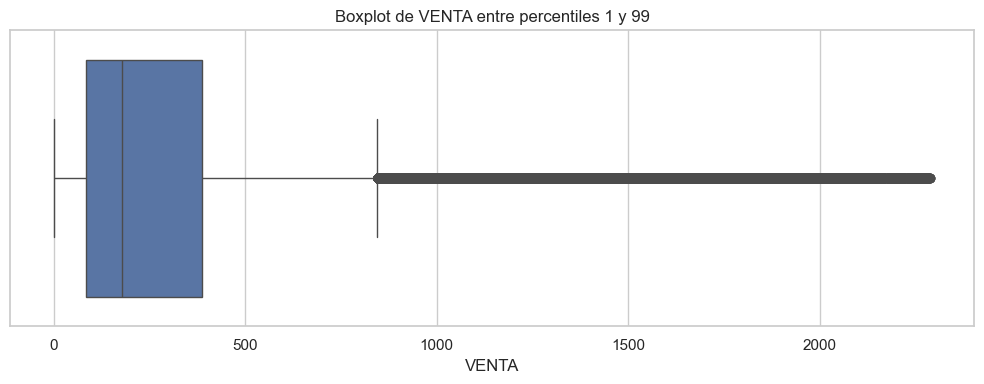

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_venta_p01_p99.png


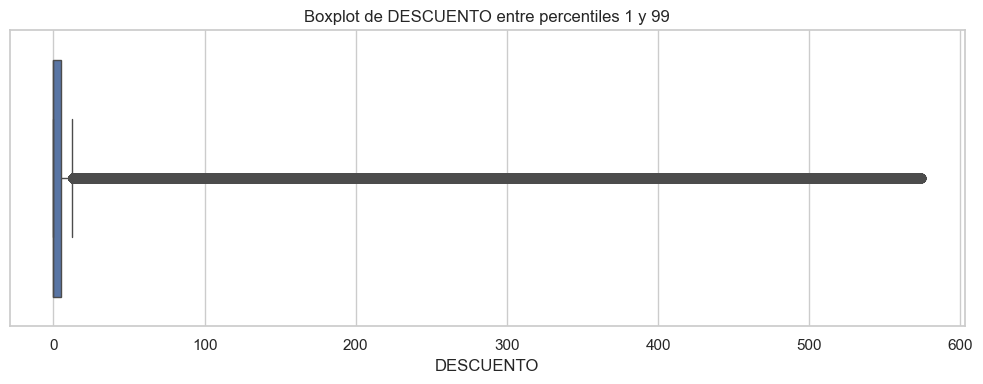

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_descuento_p01_p99.png


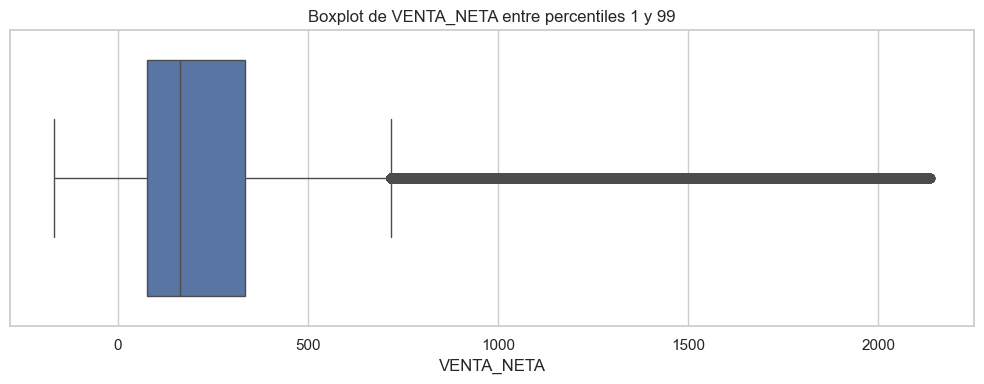

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_venta_neta_p01_p99.png


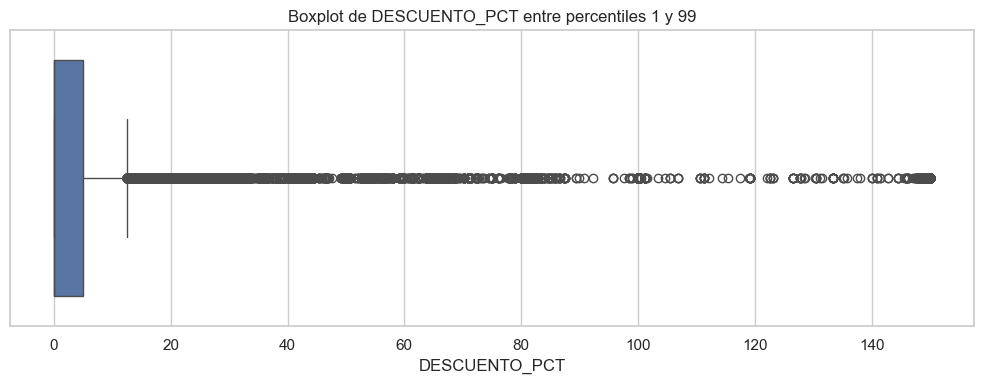

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_descuento_pct_p01_p99.png


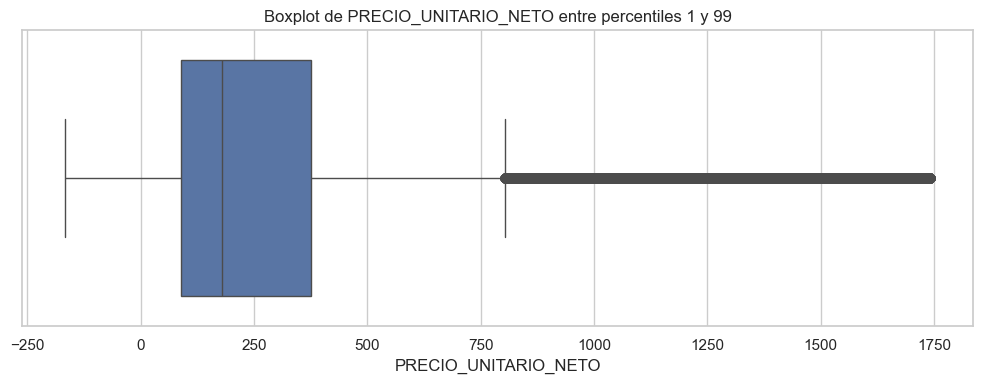

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\boxplot_precio_unitario_neto_p01_p99.png


In [16]:
# ===============================
# Boxplots recortados al percentil 99
# ===============================

for col in variables_outliers:
    temp = df[df[col].notna()].copy()
    
    p01 = temp[col].quantile(0.01)
    p99 = temp[col].quantile(0.99)
    
    temp_recortado = temp[(temp[col] >= p01) & (temp[col] <= p99)]
    
    plt.figure(figsize=(10, 4))
    
    sns.boxplot(
        data=temp_recortado,
        x=col
    )
    
    plt.title(f"Boxplot de {col} entre percentiles 1 y 99")
    plt.xlabel(col)
    plt.tight_layout()
    
    output_fig = OUTLIERS_FIGURES_DIR / f"boxplot_{col.lower()}_p01_p99.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print(f"Figura guardada en: {output_fig}")

In [17]:
# ===============================
# Ventas negativas
# ===============================

ventas_negativas = df[df["VENTA"] < 0].copy()

print(f"Filas con venta negativa: {len(ventas_negativas):,}")
print(f"Porcentaje: {len(ventas_negativas) / len(df) * 100:.4f}%")
print(f"Venta negativa total: {ventas_negativas['VENTA'].sum():,.2f}")
print(f"Venta neta asociada: {ventas_negativas['VENTA_NETA'].sum():,.2f}")

ventas_negativas[[
    "NroReg", "FECHA", "PDV", "FACTURA", "CATEG", "PLU_SAP",
    "CANT", "VENTA", "DESCUENTO", "VENTA_NETA",
    "PROMO_FLAG", "TIPO_PROMO"
]].head(30)

Filas con venta negativa: 1,763
Porcentaje: 0.4303%
Venta negativa total: -562,090.00
Venta neta asociada: -1,609,853.00


,NroReg,FECHA,PDV,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,PROMO_FLAG,TIPO_PROMO
586,14729,2023-01-02,980,437,08029,1115190,-1.00,-438.00,0.00,-438.00,False,Sin promoción
2041,53861,2023-01-05,980,1510,04010,1334627,-1.00,-228.00,0.00,-228.00,False,Sin promoción
2365,60839,2023-01-06,980,1764,04010,1033944,1.00,-638.00,957.00,"-1,595.00",True,Oferta y descuento
2749,67332,2023-01-06,1255,1758,04010,1026091,1.00,-314.00,598.00,-912.00,True,Oferta y descuento
3112,74035,2023-01-07,1255,2308,04010,1129748,0.00,-154.00,0.00,-154.00,False,Sin promoción
3204,75775,2023-01-07,980,2368,04010,1313279,1.00,-245.00,420.00,-665.00,True,Oferta y descuento
3432,79470,2023-01-08,1255,2519,04010,1331490,1.00,-35.00,104.00,-139.00,True,Oferta y descuento
3519,80912,2023-01-08,980,2592,04010,1313279,1.00,-105.00,280.00,-385.00,True,Oferta y descuento
3785,85867,2023-01-08,1255,2771,08061,1013114,-1.00,-41.00,0.00,-41.00,False,Sin promoción
4105,92833,2023-01-09,980,2993,04010,1128198,1.00,-43.00,258.00,-301.00,True,Oferta y descuento


In [18]:
# ===============================
# Cantidades negativas
# ===============================

cantidades_negativas = df[df["CANT"] < 0].copy()

print(f"Filas con cantidad negativa: {len(cantidades_negativas):,}")
print(f"Porcentaje: {len(cantidades_negativas) / len(df) * 100:.4f}%")
print(f"Cantidad negativa total: {cantidades_negativas['CANT'].sum():,.2f}")
print(f"Venta neta asociada: {cantidades_negativas['VENTA_NETA'].sum():,.2f}")

cantidades_negativas[[
    "NroReg", "FECHA", "PDV", "FACTURA", "CATEG", "PLU_SAP",
    "CANT", "VENTA", "DESCUENTO", "VENTA_NETA",
    "PROMO_FLAG", "TIPO_PROMO"
]].head(30)

Filas con cantidad negativa: 133
Porcentaje: 0.0325%
Cantidad negativa total: -263.52
Venta neta asociada: -131,861.00


,NroReg,FECHA,PDV,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,PROMO_FLAG,TIPO_PROMO
586,14729,2023-01-02,980,437,08029,1115190,-1.00,-438.00,0.00,-438.00,False,Sin promoción
2041,53861,2023-01-05,980,1510,04010,1334627,-1.00,-228.00,0.00,-228.00,False,Sin promoción
3785,85867,2023-01-08,1255,2771,08061,1013114,-1.00,-41.00,0.00,-41.00,False,Sin promoción
4783,111453,2023-01-11,1311,3478,08042,1194236,-1.00,-79.00,-14.00,-65.00,True,Solo oferta
4790,111740,2023-01-11,1311,3478,08042,1189178,-1.00,-430.00,-76.00,-354.00,True,Solo oferta
4810,112288,2023-01-11,1311,3478,08029,1013410,-1.00,-321.00,-57.00,-264.00,True,Solo oferta
4928,115521,2023-01-11,1311,3599,08062,1350391,-3.00,"-4,885.00",-862.00,"-4,023.00",True,Solo oferta
5055,118721,2023-01-11,1311,3478,08029,1227143,-1.00,-565.00,-100.00,-465.00,True,Solo oferta
5115,120373,2023-01-11,1311,3478,08061,1008390,-1.00,-142.00,-26.00,-116.00,True,Solo oferta
5155,121415,2023-01-11,1311,3478,08061,1292233,-1.00,-637.00,-113.00,-524.00,True,Solo oferta


In [19]:
# ===============================
# Ventas iguales a cero
# ===============================

ventas_cero = df[df["VENTA"] == 0].copy()

print(f"Filas con venta igual a cero: {len(ventas_cero):,}")
print(f"Porcentaje: {len(ventas_cero) / len(df) * 100:.4f}%")
print(f"Descuento asociado: {ventas_cero['DESCUENTO'].sum():,.2f}")
print(f"Venta neta asociada: {ventas_cero['VENTA_NETA'].sum():,.2f}")

ventas_cero[[
    "NroReg", "FECHA", "PDV", "FACTURA", "CATEG", "PLU_SAP",
    "CANT", "VENTA", "DESCUENTO", "VENTA_NETA",
    "PROMO_FLAG", "TIPO_PROMO"
]].head(30)

Filas con venta igual a cero: 3,470
Porcentaje: 0.8468%
Descuento asociado: 398,192.00
Venta neta asociada: -398,192.00


,NroReg,FECHA,PDV,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,PROMO_FLAG,TIPO_PROMO
123,2448,2023-01-01,980,106,04010,1036245,0.00,0.00,0.00,0.00,False,Sin promoción
195,4362,2023-01-01,1255,152,08061,1008762,0.00,0.00,0.00,0.00,False,Sin promoción
401,9527,2023-01-02,980,313,04010,1342490,0.00,0.00,0.00,0.00,False,Sin promoción
524,13053,2023-01-02,1311,211,08029,1013410,0.00,0.00,0.00,0.00,False,Sin promoción
656,16410,2023-01-02,1255,366,08061,1011233,0.00,0.00,0.00,0.00,False,Sin promoción
697,17386,2023-01-02,980,239,08029,1297744,0.00,0.00,0.00,0.00,False,Sin promoción
732,18424,2023-01-03,1255,526,04010,1023733,0.00,0.00,0.00,0.00,False,Sin promoción
751,18912,2023-01-03,980,544,04010,1036245,0.00,0.00,0.00,0.00,False,Sin promoción
1331,35418,2023-01-04,1255,916,08029,1227143,0.00,0.00,0.00,0.00,False,Sin promoción
1412,37665,2023-01-04,1255,1039,08029,1227143,0.00,0.00,0.00,0.00,False,Sin promoción


In [20]:
# ===============================
# Descuentos mayores que venta
# ===============================

descuento_mayor_venta = df[df["DESCUENTO"] > df["VENTA"]].copy()

print(f"Filas con descuento mayor que venta: {len(descuento_mayor_venta):,}")
print(f"Porcentaje: {len(descuento_mayor_venta) / len(df) * 100:.4f}%")
print(f"Venta bruta asociada: {descuento_mayor_venta['VENTA'].sum():,.2f}")
print(f"Descuento asociado: {descuento_mayor_venta['DESCUENTO'].sum():,.2f}")
print(f"Venta neta asociada: {descuento_mayor_venta['VENTA_NETA'].sum():,.2f}")

descuento_mayor_venta[[
    "NroReg", "FECHA", "PDV", "FACTURA", "CATEG", "PLU_SAP",
    "CANT", "VENTA", "DESCUENTO", "VENTA_NETA",
    "DESCUENTO_PCT", "PROMO_FLAG", "TIPO_PROMO"
]].head(30)

Filas con descuento mayor que venta: 8,799
Porcentaje: 2.1474%
Venta bruta asociada: 565,541.00
Descuento asociado: 3,776,785.00
Venta neta asociada: -3,211,244.00


,NroReg,FECHA,PDV,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PROMO_FLAG,TIPO_PROMO
366,8554,2023-01-02,1255,288,08042,1341191,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento
586,14729,2023-01-02,980,437,08029,1115190,-1.00,-438.00,0.00,-438.00,NaN,False,Sin promoción
601,15053,2023-01-02,1255,447,08042,1341191,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento
2041,53861,2023-01-05,980,1510,04010,1334627,-1.00,-228.00,0.00,-228.00,NaN,False,Sin promoción
2181,57343,2023-01-06,980,1596,04010,1153834,1.00,249.00,374.00,-125.00,150.20,True,Oferta y descuento
2218,57837,2023-01-06,980,1638,04010,1036252,1.00,0.00,120.00,-120.00,NaN,True,Oferta y descuento
2220,57847,2023-01-06,980,1640,04010,1129746,1.00,204.00,307.00,-103.00,150.49,True,Oferta y descuento
2234,58044,2023-01-06,1311,1654,04010,1249844,1.00,219.00,329.00,-110.00,150.23,True,Oferta y descuento
2258,58631,2023-01-06,1255,1676,04010,1023640,1.00,179.00,269.00,-90.00,150.28,True,Oferta y descuento
2295,59480,2023-01-06,1255,1599,08042,1341191,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento


In [21]:
# ===============================
# Venta neta negativa
# ===============================

venta_neta_negativa = df[df["VENTA_NETA"] < 0].copy()

print(f"Filas con venta neta negativa: {len(venta_neta_negativa):,}")
print(f"Porcentaje: {len(venta_neta_negativa) / len(df) * 100:.4f}%")
print(f"Venta bruta asociada: {venta_neta_negativa['VENTA'].sum():,.2f}")
print(f"Descuento asociado: {venta_neta_negativa['DESCUENTO'].sum():,.2f}")
print(f"Venta neta total: {venta_neta_negativa['VENTA_NETA'].sum():,.2f}")

venta_neta_negativa[[
    "NroReg", "FECHA", "PDV", "FACTURA", "CATEG", "PLU_SAP",
    "CANT", "VENTA", "DESCUENTO", "VENTA_NETA",
    "DESCUENTO_PCT", "PROMO_FLAG", "TIPO_PROMO"
]].head(30)

Filas con venta neta negativa: 8,799
Porcentaje: 2.1474%
Venta bruta asociada: 565,541.00
Descuento asociado: 3,776,785.00
Venta neta total: -3,211,244.00


,NroReg,FECHA,PDV,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PROMO_FLAG,TIPO_PROMO
366,8554,2023-01-02,1255,288,08042,1341191,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento
586,14729,2023-01-02,980,437,08029,1115190,-1.00,-438.00,0.00,-438.00,NaN,False,Sin promoción
601,15053,2023-01-02,1255,447,08042,1341191,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento
2041,53861,2023-01-05,980,1510,04010,1334627,-1.00,-228.00,0.00,-228.00,NaN,False,Sin promoción
2181,57343,2023-01-06,980,1596,04010,1153834,1.00,249.00,374.00,-125.00,150.20,True,Oferta y descuento
2218,57837,2023-01-06,980,1638,04010,1036252,1.00,0.00,120.00,-120.00,NaN,True,Oferta y descuento
2220,57847,2023-01-06,980,1640,04010,1129746,1.00,204.00,307.00,-103.00,150.49,True,Oferta y descuento
2234,58044,2023-01-06,1311,1654,04010,1249844,1.00,219.00,329.00,-110.00,150.23,True,Oferta y descuento
2258,58631,2023-01-06,1255,1676,04010,1023640,1.00,179.00,269.00,-90.00,150.28,True,Oferta y descuento
2295,59480,2023-01-06,1255,1599,08042,1341191,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento


In [22]:
# ===============================
# Venta neta negativa por PDV y categoría
# ===============================

venta_negativa_pdv_categoria = (
    venta_neta_negativa.groupby(["PDV", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        productos=("PLU_SAP", "nunique"),
        tickets=("TICKET_ID", "nunique")
    )
    .reset_index()
    .sort_values("filas", ascending=False)
)

venta_negativa_pdv_categoria

,PDV,CATEG,filas,venta_bruta,descuento,venta_neta,productos,tickets
6,1311,04010,2393,"183,629.00","1,228,123.00","-1,044,494.00",385,2147
0,1255,04010,1889,"285,490.00","959,609.00","-674,119.00",263,1630
12,980,04010,1706,"-24,309.00","433,403.00","-457,712.00",202,1620
7,1311,08029,597,"33,695.00","110,098.00","-76,403.00",175,550
13,980,08029,405,"22,067.00","305,522.00","-283,455.00",67,380
8,1311,08042,374,"19,130.00","215,948.00","-196,818.00",195,333
1,1255,08029,323,"14,873.00","69,597.00","-54,724.00",132,283
9,1311,08061,299,"11,542.00","44,933.00","-33,391.00",133,279
10,1311,08062,225,"21,798.00","200,452.00","-178,654.00",121,206
2,1255,08042,187,"12,945.00","82,242.00","-69,297.00",75,182


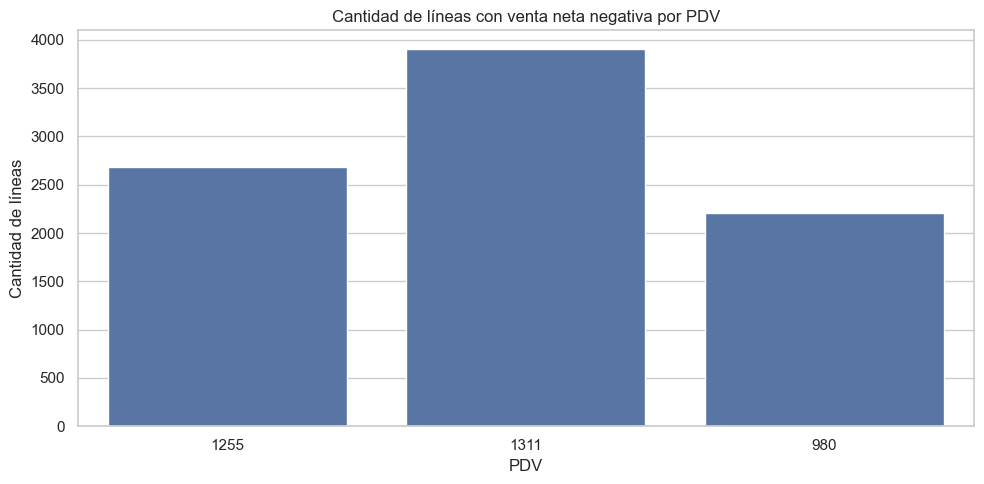

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\venta_neta_negativa_por_pdv.png


In [23]:
# ===============================
# Gráfico venta neta negativa por PDV
# ===============================

venta_negativa_pdv = (
    venta_neta_negativa.groupby("PDV")
    .agg(
        filas=("NroReg", "count"),
        venta_neta=("VENTA_NETA", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=venta_negativa_pdv,
    x="PDV",
    y="filas"
)

plt.title("Cantidad de líneas con venta neta negativa por PDV")
plt.xlabel("PDV")
plt.ylabel("Cantidad de líneas")
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "venta_neta_negativa_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [24]:
# ===============================
# Agregación diaria para detectar días atípicos
# ===============================

ventas_diarias = (
    df.groupby("FECHA")
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

ventas_diarias["promo_pct_lineas"] = np.where(
    ventas_diarias["filas"] > 0,
    ventas_diarias["lineas_promo"] / ventas_diarias["filas"] * 100,
    np.nan
)

ventas_diarias["registros_especiales_pct"] = np.where(
    ventas_diarias["filas"] > 0,
    ventas_diarias["registros_especiales"] / ventas_diarias["filas"] * 100,
    np.nan
)

resultado_dias = detectar_outliers_iqr(ventas_diarias, "venta_neta")

ventas_diarias["FLAG_DIA_ATIPICO_VENTA_NETA"] = resultado_dias["outliers"]

dias_atipicos = ventas_diarias[ventas_diarias["FLAG_DIA_ATIPICO_VENTA_NETA"]].copy()

print(f"Días atípicos por venta neta: {len(dias_atipicos):,}")
print(f"Límite inferior: {resultado_dias['limite_inferior']:,.2f}")
print(f"Límite superior: {resultado_dias['limite_superior']:,.2f}")

dias_atipicos.sort_values("venta_neta", ascending=False)

Días atípicos por venta neta: 74
Límite inferior: -9,012.50
Límite superior: 292,123.50


,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,registros_especiales,promo_pct_lineas,registros_especiales_pct,FLAG_DIA_ATIPICO_VENTA_NETA
89,2023-03-31,2803,"1,403,638.00","418,265.00","985,373.00","3,722.57",1182,1316,2124,178,75.78,6.35,True
150,2023-05-31,2597,"1,252,438.00","373,578.00","878,860.00","3,890.00",1090,1218,2040,131,78.55,5.04,True
303,2023-10-31,2492,"1,263,378.00","413,990.00","849,388.00","2,775.78",975,1180,1946,122,78.09,4.90,True
242,2023-08-31,2509,"1,233,572.00","397,812.00","835,760.00","2,748.81",1026,1143,1926,162,76.76,6.46,True
333,2023-11-30,2142,"1,066,861.00","252,030.00","814,831.00","2,459.74",884,1038,1516,133,70.77,6.21,True
30,2023-01-31,2576,"1,180,602.00","368,333.00","812,269.00","2,891.25",1031,1198,2038,119,79.11,4.62,True
180,2023-06-30,2661,"1,155,900.00","365,658.00","790,242.00","2,949.93",1143,1221,2011,152,75.57,5.71,True
58,2023-02-28,2171,"973,403.00","241,293.00","732,110.00","2,320.39",936,1077,1727,74,79.55,3.41,True
395,2024-01-31,2248,"986,675.00","283,473.00","703,202.00","2,380.10",974,1115,1633,88,72.64,3.91,True
424,2024-02-29,1759,"842,923.00","158,519.00","684,404.00","2,745.99",753,923,1213,90,68.96,5.12,True


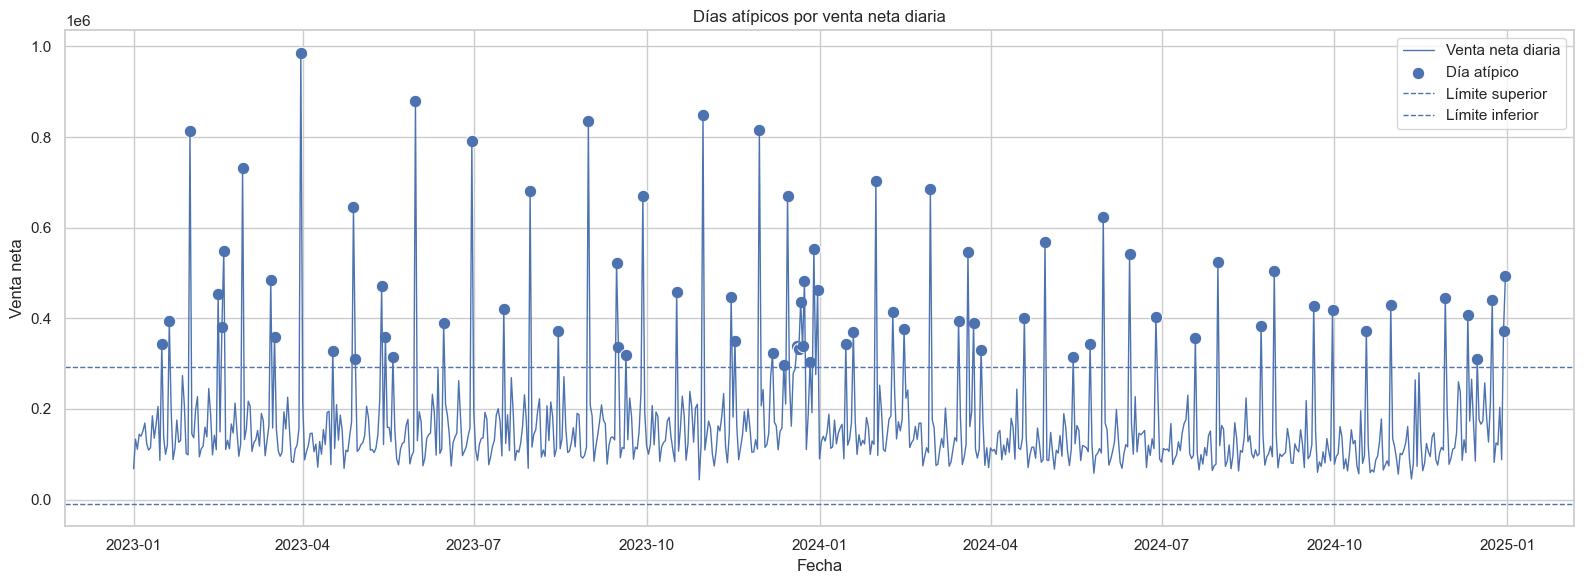

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\dias_atipicos_venta_neta.png


In [25]:
# ===============================
# Serie diaria con días atípicos
# ===============================

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=ventas_diarias,
    x="FECHA",
    y="venta_neta",
    linewidth=1,
    label="Venta neta diaria"
)

sns.scatterplot(
    data=dias_atipicos,
    x="FECHA",
    y="venta_neta",
    s=80,
    label="Día atípico"
)

plt.axhline(resultado_dias["limite_superior"], linestyle="--", linewidth=1, label="Límite superior")
plt.axhline(resultado_dias["limite_inferior"], linestyle="--", linewidth=1, label="Límite inferior")

plt.title("Días atípicos por venta neta diaria")
plt.xlabel("Fecha")
plt.ylabel("Venta neta")
plt.legend()
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "dias_atipicos_venta_neta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [26]:
# ===============================
# Top y bottom días por venta neta
# ===============================

top_dias = ventas_diarias.sort_values("venta_neta", ascending=False).head(20)
bottom_dias = ventas_diarias.sort_values("venta_neta", ascending=True).head(20)

display(top_dias)
display(bottom_dias)

,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,registros_especiales,promo_pct_lineas,registros_especiales_pct,FLAG_DIA_ATIPICO_VENTA_NETA
89,2023-03-31,2803,"1,403,638.00","418,265.00","985,373.00","3,722.57",1182,1316,2124,178,75.78,6.35,True
150,2023-05-31,2597,"1,252,438.00","373,578.00","878,860.00","3,890.00",1090,1218,2040,131,78.55,5.04,True
303,2023-10-31,2492,"1,263,378.00","413,990.00","849,388.00","2,775.78",975,1180,1946,122,78.09,4.90,True
242,2023-08-31,2509,"1,233,572.00","397,812.00","835,760.00","2,748.81",1026,1143,1926,162,76.76,6.46,True
333,2023-11-30,2142,"1,066,861.00","252,030.00","814,831.00","2,459.74",884,1038,1516,133,70.77,6.21,True
30,2023-01-31,2576,"1,180,602.00","368,333.00","812,269.00","2,891.25",1031,1198,2038,119,79.11,4.62,True
180,2023-06-30,2661,"1,155,900.00","365,658.00","790,242.00","2,949.93",1143,1221,2011,152,75.57,5.71,True
58,2023-02-28,2171,"973,403.00","241,293.00","732,110.00","2,320.39",936,1077,1727,74,79.55,3.41,True
395,2024-01-31,2248,"986,675.00","283,473.00","703,202.00","2,380.10",974,1115,1633,88,72.64,3.91,True
424,2024-02-29,1759,"842,923.00","158,519.00","684,404.00","2,745.99",753,923,1213,90,68.96,5.12,True


,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,registros_especiales,promo_pct_lineas,registros_especiales_pct,FLAG_DIA_ATIPICO_VENTA_NETA
301,2023-10-29,183,"44,922.00","1,242.00","43,680.00",184.58,139,157,15,3,8.20,1.64,False
680,2024-11-11,206,"47,032.00","1,460.00","45,572.00",214.05,155,152,22,6,10.68,2.91,False
673,2024-11-04,207,"57,483.00","1,352.00","56,131.00",217.99,157,146,16,3,7.73,1.45,False
652,2024-10-14,239,"58,924.00","1,889.00","57,035.00",251.23,181,165,25,6,10.46,2.51,False
511,2024-05-26,249,"63,886.00","5,374.00","58,512.00",297.73,185,166,34,6,13.65,2.41,False
658,2024-10-20,215,"62,166.00","2,569.00","59,597.00",248.10,158,154,39,4,18.14,1.86,False
630,2024-09-22,227,"63,248.00","2,865.00","60,383.00",265.93,173,154,36,2,15.86,0.88,False
660,2024-10-22,244,"64,353.00","3,315.00","61,038.00",223.19,196,188,41,3,16.80,1.23,False
588,2024-08-11,246,"67,527.00","4,307.00","63,220.00",275.99,187,172,35,7,14.23,2.85,False
646,2024-10-08,259,"64,587.00","1,264.00","63,323.00",255.11,206,199,17,2,6.56,0.77,False


In [27]:
# ===============================
# Agregación por producto
# ===============================

productos = (
    df.groupby("PLU_SAP")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        pdv=("PDV", "nunique"),
        categorias=("CATEG", "nunique"),
        categoria_principal=("CATEG", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        tickets=("TICKET_ID", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

productos["precio_unitario_neto_promedio"] = np.where(
    productos["unidades"] > 0,
    productos["venta_neta"] / productos["unidades"],
    np.nan
)

productos["promo_pct_lineas"] = np.where(
    productos["filas"] > 0,
    productos["lineas_promo"] / productos["filas"] * 100,
    np.nan
)

productos["registros_especiales_pct"] = np.where(
    productos["filas"] > 0,
    productos["registros_especiales"] / productos["filas"] * 100,
    np.nan
)

productos.head()

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,precio_unitario_neto_promedio,promo_pct_lineas,registros_especiales_pct
0,100131,17,13,2,1,08067,13,"23,896.00",0.00,"23,896.00",25.00,0,2,955.84,0.00,11.76
1,100191,13,10,2,1,08067,10,"3,211.00",0.00,"3,211.00",10.00,0,2,321.10,0.00,15.38
2,100306,1,1,1,1,08067,1,292.00,0.00,292.00,1.00,0,0,292.00,0.00,0.00
3,100317,3,3,1,1,08067,3,"2,700.00",0.00,"2,700.00",3.00,0,0,900.00,0.00,0.00
4,100343,1,1,1,1,08067,1,207.00,0.00,207.00,1.00,0,0,207.00,0.00,0.00


In [28]:
# ===============================
# Outliers por producto
# ===============================

variables_producto_outlier = [
    "venta_neta",
    "unidades",
    "tickets",
    "precio_unitario_neto_promedio",
    "promo_pct_lineas",
    "registros_especiales_pct"
]

resumen_outliers_producto = []

for col in variables_producto_outlier:
    temp = productos[productos[col].notna()].copy()
    resultado = detectar_outliers_iqr(temp, col)
    
    productos[f"OUTLIER_{col.upper()}"] = False
    productos.loc[temp.index, f"OUTLIER_{col.upper()}"] = resultado["outliers"]
    
    resumen_outliers_producto.append({
        "variable": col,
        "q1": resultado["q1"],
        "q3": resultado["q3"],
        "iqr": resultado["iqr"],
        "limite_inferior": resultado["limite_inferior"],
        "limite_superior": resultado["limite_superior"],
        "outliers": resultado["n_outliers"],
        "outliers_pct": resultado["pct_outliers"]
    })

resumen_outliers_producto = pd.DataFrame(resumen_outliers_producto)

productos["OUTLIER_PRODUCTO_GENERAL"] = productos[
    [f"OUTLIER_{col.upper()}" for col in variables_producto_outlier]
].any(axis=1)

resumen_outliers_producto

,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers,outliers_pct
0,venta_neta,"1,537.50","16,823.50","15,286.00","-21,391.50","39,752.50",626,10.37
1,unidades,4.00,48.00,44.00,-62.00,114.00,710,11.76
2,tickets,4.00,44.50,40.50,-56.75,105.25,733,12.14
3,precio_unitario_neto_promedio,177.01,661.04,484.02,-549.02,"1,387.07",347,5.81
4,promo_pct_lineas,9.09,50.00,40.91,-52.27,111.36,0,0.00
5,registros_especiales_pct,0.00,2.10,2.10,-3.15,5.25,1041,17.24


In [29]:
# ===============================
# Productos extremos por venta neta
# ===============================

productos_extremos_venta = productos[
    productos["OUTLIER_VENTA_NETA"]
].sort_values("venta_neta", ascending=False)

print(f"Productos outlier por venta neta: {len(productos_extremos_venta):,}")

productos_extremos_venta.head(30)

Productos outlier por venta neta: 626


,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,precio_unitario_neto_promedio,promo_pct_lineas,registros_especiales_pct,OUTLIER_VENTA_NETA,OUTLIER_UNIDADES,OUTLIER_TICKETS,OUTLIER_PRECIO_UNITARIO_NETO_PROMEDIO,OUTLIER_PROMO_PCT_LINEAS,OUTLIER_REGISTROS_ESPECIALES_PCT,OUTLIER_PRODUCTO_GENERAL
1513,1036246,7872,719,3,1,04010,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,181.40,10.32,1.82,True,True,True,False,False,False,True
1518,1036266,4699,697,3,1,04010,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,113.25,19.17,3.11,True,True,True,False,False,False,True
4657,1331944,2142,569,3,1,04010,2117,"1,380,941.00","11,793.00","1,369,148.00","3,143.00",96,5,435.62,4.48,0.23,True,True,True,False,False,False,True
4936,1338873,8419,701,3,1,04010,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,97.11,15.19,0.39,True,True,True,False,False,False,True
3166,1246431,842,79,3,1,08029,627,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",613,133,786.47,72.80,15.80,True,True,True,False,False,True,True
1515,1036252,5075,708,3,1,04010,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,145.57,18.23,4.08,True,True,True,False,False,False,True
1516,1036253,2824,633,3,1,04010,2682,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",601,194,84.23,21.28,6.87,True,True,True,False,False,True,True
4155,1313279,4665,695,3,1,04010,4299,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",980,126,155.32,21.01,2.70,True,True,True,False,False,False,True
1324,1023807,663,345,3,1,04010,615,"1,113,652.00","118,599.00","995,053.00",771.00,243,20,"1,290.60",36.65,3.02,True,True,True,False,False,False,True
1556,1041245,803,410,3,1,04010,793,"980,909.00","85,998.00","894,911.00","2,724.00",69,11,328.53,8.59,1.37,True,True,True,False,False,False,True


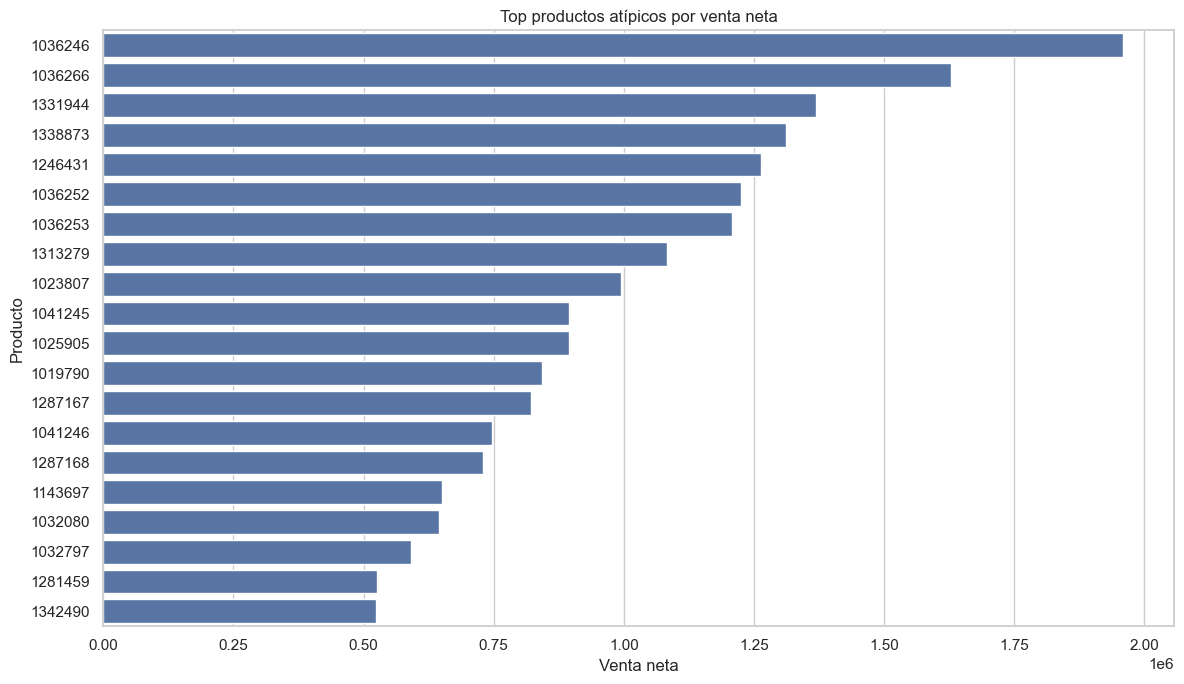

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\productos_atipicos_venta_neta.png


In [30]:
# ===============================
# Gráfico productos extremos por venta neta
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=productos_extremos_venta.head(20),
    y="PLU_SAP",
    x="venta_neta"
)

plt.title("Top productos atípicos por venta neta")
plt.xlabel("Venta neta")
plt.ylabel("Producto")
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "productos_atipicos_venta_neta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [31]:
# ===============================
# Productos con precio unitario neto extremo
# ===============================

productos_precio_extremo = productos[
    productos["OUTLIER_PRECIO_UNITARIO_NETO_PROMEDIO"]
].sort_values("precio_unitario_neto_promedio", ascending=False)

print(f"Productos con precio unitario neto promedio atípico: {len(productos_precio_extremo):,}")

productos_precio_extremo.head(30)

Productos con precio unitario neto promedio atípico: 347


,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,precio_unitario_neto_promedio,promo_pct_lineas,registros_especiales_pct,OUTLIER_VENTA_NETA,OUTLIER_UNIDADES,OUTLIER_TICKETS,OUTLIER_PRECIO_UNITARIO_NETO_PROMEDIO,OUTLIER_PROMO_PCT_LINEAS,OUTLIER_REGISTROS_ESPECIALES_PCT,OUTLIER_PRODUCTO_GENERAL
1894,1122725,4,4,2,1,08061,4,"14,813.00","2,151.00","12,662.00",0.12,3,0,"105,516.67",75.00,0.00,False,False,False,True,False,False,True
5935,70420,1,1,1,1,08067,1,"1,413.00",0.00,"1,413.00",0.09,0,0,"15,543.00",0.00,0.00,False,False,False,True,False,False,True
1613,106805,1,1,1,1,08067,1,"14,130.00",0.00,"14,130.00",1.00,0,0,"14,130.00",0.00,0.00,False,False,False,True,False,False,True
1605,105776,1,1,1,1,08067,1,"12,410.00",0.00,"12,410.00",1.00,0,0,"12,410.00",0.00,0.00,False,False,False,True,False,False,True
1990,1130226,1,1,1,1,08042,1,"11,645.00","2,055.00","9,590.00",1.00,1,0,"9,590.00",100.00,0.00,False,False,False,True,False,False,True
2402,1166247,2,2,1,1,04010,2,"18,700.00",0.00,"18,700.00",2.00,0,0,"9,350.00",0.00,0.00,False,False,False,True,False,False,True
4464,1323564,1,1,1,1,04010,1,"9,000.00",0.00,"9,000.00",1.00,0,0,"9,000.00",0.00,0.00,False,False,False,True,False,False,True
4177,1314228,2,2,1,1,04010,2,"26,389.00",0.00,"26,389.00",3.00,0,0,"8,796.33",0.00,0.00,False,False,False,True,False,False,True
1612,106784,1,1,1,1,08067,1,"2,826.00",0.00,"2,826.00",0.33,0,0,"8,478.00",0.00,0.00,False,False,False,True,False,False,True
975,1017863,1,1,1,1,08042,1,"10,287.00","1,815.00","8,472.00",1.00,1,0,"8,472.00",100.00,0.00,False,False,False,True,False,False,True


In [32]:
# ===============================
# Cargar o reconstruir base de tickets
# ===============================

if TICKETS_FILE.exists():
    tickets = pd.read_parquet(TICKETS_FILE)
    tickets["fecha"] = pd.to_datetime(tickets["fecha"], errors="coerce")
    print("Base de tickets cargada desde archivo.")
else:
    tickets = (
        df.groupby("TICKET_ID")
        .agg(
            fecha=("FECHA", "first"),
            anio=("ANIO", "first"),
            mes=("MES", "first"),
            pdv=("PDV", "first"),
            estrato=("Estrato", "first"),
            factura=("FACTURA", "first"),
            lineas=("NroReg", "count"),
            productos_distintos=("PLU_SAP", "nunique"),
            categorias_distintas=("CATEG", "nunique"),
            venta_bruta=("VENTA", "sum"),
            descuento=("DESCUENTO", "sum"),
            venta_neta=("VENTA_NETA", "sum"),
            unidades=("CANT", "sum"),
            lineas_promo=("PROMO_FLAG", "sum"),
            registros_especiales=("REGISTRO_ESPECIAL", "sum")
        )
        .reset_index()
    )
    
    tickets["descuento_pct"] = np.where(
        tickets["venta_bruta"] > 0,
        tickets["descuento"] / tickets["venta_bruta"] * 100,
        np.nan
    )
    
    tickets["promo_flag_ticket"] = tickets["lineas_promo"] > 0
    
    print("Base de tickets reconstruida.")

print(f"Tickets: {tickets.shape[0]:,}")
tickets.head()

Base de tickets cargada desde archivo.
Tickets: 276,989


,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket,FLAG_TICKET_ATIPICO_BAJO,FLAG_TICKET_ATIPICO_ALTO,FLAG_TICKET_ATIPICO
0,2023-01-01_1255_10,2023-01-01,2023,1,6,Domingo,1255,4,10,1,1,1,72.00,0.00,72.00,1.00,0,0,1,0.00,False,0.00,1.00,72.00,False,False,False,False
1,2023-01-01_1255_100,2023-01-01,2023,1,6,Domingo,1255,4,100,1,1,1,354.00,0.00,354.00,1.00,0,0,1,0.00,False,0.00,1.00,354.00,False,False,False,False
2,2023-01-01_1255_104,2023-01-01,2023,1,6,Domingo,1255,4,104,2,2,1,270.00,0.00,270.00,2.00,0,0,2,0.00,False,0.00,1.00,135.00,False,False,False,False
3,2023-01-01_1255_105,2023-01-01,2023,1,6,Domingo,1255,4,105,2,2,1,"1,240.00",0.00,"1,240.00",8.00,0,0,2,0.00,False,0.00,4.00,620.00,False,False,True,True
4,2023-01-01_1255_107,2023-01-01,2023,1,6,Domingo,1255,4,107,1,1,1,376.00,0.00,376.00,1.00,0,0,1,0.00,False,0.00,1.00,376.00,False,False,False,False


In [33]:
# ===============================
# Outliers de tickets
# ===============================

variables_ticket_outlier = [
    "lineas",
    "productos_distintos",
    "categorias_distintas",
    "venta_bruta",
    "descuento",
    "venta_neta",
    "unidades",
    "descuento_pct"
]

resumen_outliers_ticket = []

for col in variables_ticket_outlier:
    temp = tickets[tickets[col].notna()].copy()
    resultado = detectar_outliers_iqr(temp, col)
    
    tickets[f"OUTLIER_{col.upper()}"] = False
    tickets.loc[temp.index, f"OUTLIER_{col.upper()}"] = resultado["outliers"]
    
    resumen_outliers_ticket.append({
        "variable": col,
        "q1": resultado["q1"],
        "q3": resultado["q3"],
        "iqr": resultado["iqr"],
        "limite_inferior": resultado["limite_inferior"],
        "limite_superior": resultado["limite_superior"],
        "outliers": resultado["n_outliers"],
        "outliers_pct": resultado["pct_outliers"]
    })

resumen_outliers_ticket = pd.DataFrame(resumen_outliers_ticket)

tickets["OUTLIER_TICKET_GENERAL"] = tickets[
    [f"OUTLIER_{col.upper()}" for col in variables_ticket_outlier]
].any(axis=1)

resumen_outliers_ticket

,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers,outliers_pct
0,lineas,1.00,2.00,1.00,-0.50,3.50,11899,4.30
1,productos_distintos,1.00,1.00,0.00,1.00,1.00,68248,24.64
2,categorias_distintas,1.00,1.00,0.00,1.00,1.00,27733,10.01
3,venta_bruta,104.00,520.00,416.00,-520.00,"1,144.00",27523,9.94
4,descuento,0.00,3.00,3.00,-4.50,7.50,66923,24.16
5,venta_neta,95.00,469.00,374.00,-466.00,"1,030.00",26474,9.56
6,unidades,1.00,2.00,1.00,-0.50,3.50,24476,8.84
7,descuento_pct,0.00,2.48,2.48,-3.72,6.21,64229,23.23


In [34]:
# ===============================
# Tickets extremos por venta neta
# ===============================

tickets_extremos_venta = tickets[
    tickets["OUTLIER_VENTA_NETA"]
].sort_values("venta_neta", ascending=False)

print(f"Tickets atípicos por venta neta: {len(tickets_extremos_venta):,}")

tickets_extremos_venta.head(30)

Tickets atípicos por venta neta: 26,474


,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket,FLAG_TICKET_ATIPICO_BAJO,FLAG_TICKET_ATIPICO_ALTO,FLAG_TICKET_ATIPICO,OUTLIER_LINEAS,OUTLIER_PRODUCTOS_DISTINTOS,OUTLIER_CATEGORIAS_DISTINTAS,OUTLIER_VENTA_BRUTA,OUTLIER_DESCUENTO,OUTLIER_VENTA_NETA,OUTLIER_UNIDADES,OUTLIER_DESCUENTO_PCT,OUTLIER_TICKET_GENERAL
183758,2024-03-20_1311_179637,2024-03-20,2024,3,2,Miércoles,1311,6,179637,1,1,1,"195,457.00",0.00,"195,457.00",45.00,0,0,1,0.00,False,0.00,45.00,"195,457.00",False,False,True,True,False,False,False,True,False,True,True,False,True
31684,2023-03-17_1311_19699,2023-03-17,2023,3,4,Viernes,1311,6,19699,1,1,1,"107,824.00","11,980.00","95,844.00",21.00,1,0,1,11.11,True,100.00,21.00,"95,844.00",False,False,True,True,False,False,False,True,True,True,True,True,True
176364,2024-02-29_1255_173042,2024-02-29,2024,2,3,Jueves,1255,4,173042,1,1,1,"95,200.00",0.00,"95,200.00",800.00,0,0,1,0.00,False,0.00,800.00,"95,200.00",False,False,True,True,False,False,False,True,False,True,True,False,True
275083,2024-12-28_1255_233169,2024-12-28,2024,12,5,Sábado,1255,4,233169,1,1,1,"78,000.00","26,000.00","52,000.00",400.00,1,0,1,33.33,True,100.00,400.00,"52,000.00",False,False,True,True,False,False,False,True,True,True,True,True,True
266414,2024-12-06_1255_205724,2024-12-06,2024,12,4,Viernes,1255,4,205724,2,1,1,"128,350.00","76,650.00","51,700.00","1,000.00",2,1,1,59.72,True,100.00,500.00,"25,850.00",True,False,True,True,False,False,False,True,True,True,True,True,True
266400,2024-12-06_1255_202435,2024-12-06,2024,12,4,Viernes,1255,4,202435,2,1,1,"128,350.00","76,650.00","51,700.00","1,000.00",2,1,1,59.72,True,100.00,500.00,"25,850.00",True,False,True,True,False,False,False,True,True,True,True,True,True
53989,2023-05-13_1255_53612,2023-05-13,2023,5,5,Sábado,1255,4,53612,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True,False,True,False,True,True,True,True,True,True
53985,2023-05-13_1255_53605,2023-05-13,2023,5,5,Sábado,1255,4,53605,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True,False,True,False,True,True,True,True,True,True
54067,2023-05-13_1255_53877,2023-05-13,2023,5,5,Sábado,1255,4,53877,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True,False,True,False,True,True,True,True,True,True
53988,2023-05-13_1255_53611,2023-05-13,2023,5,5,Sábado,1255,4,53611,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True,False,True,False,True,True,True,True,True,True


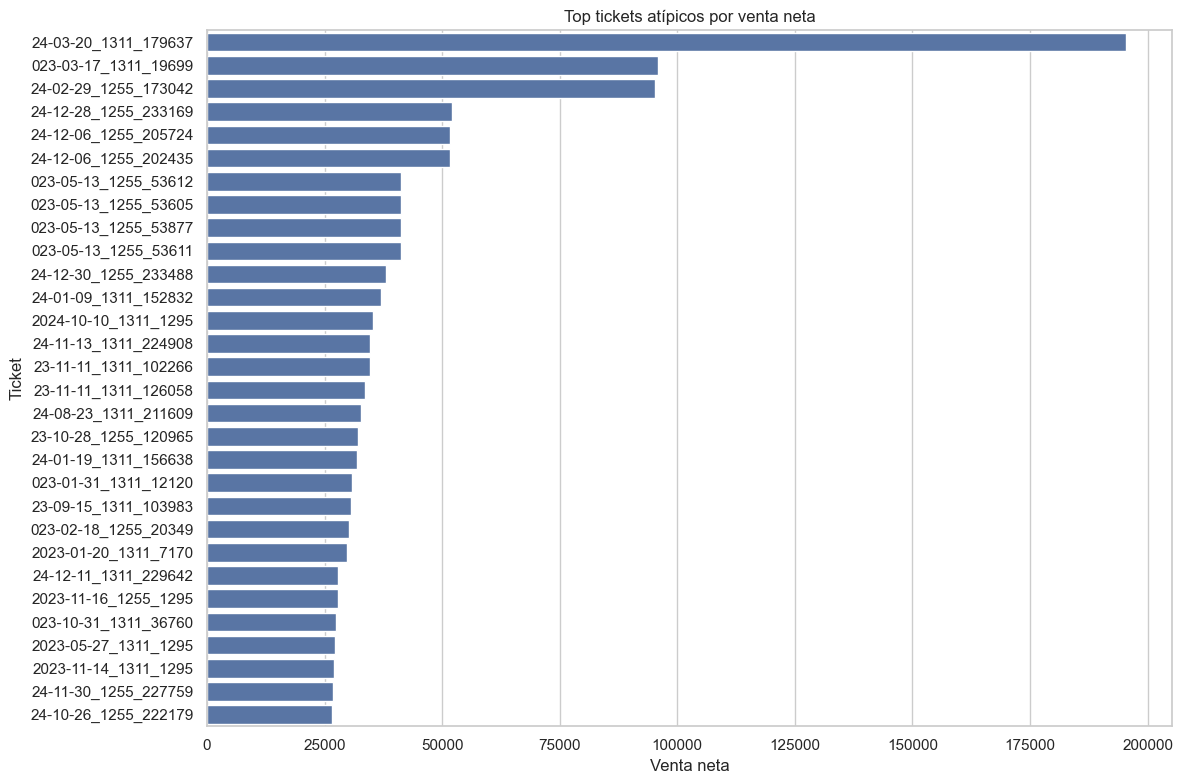

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\tickets_atipicos_venta_neta.png


In [35]:
# ===============================
# Gráfico tickets extremos por venta neta
# ===============================

tickets_extremos_plot = tickets_extremos_venta.head(30).copy()
tickets_extremos_plot["ticket_corto"] = tickets_extremos_plot["TICKET_ID"].astype(str).str[-20:]

plt.figure(figsize=(12, 8))

sns.barplot(
    data=tickets_extremos_plot,
    y="ticket_corto",
    x="venta_neta"
)

plt.title("Top tickets atípicos por venta neta")
plt.xlabel("Venta neta")
plt.ylabel("Ticket")
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "tickets_atipicos_venta_neta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [36]:
# ===============================
# Detalle de líneas de tickets atípicos principales
# ===============================

ids_tickets_extremos = tickets_extremos_venta.head(20)["TICKET_ID"].tolist()

detalle_tickets_extremos = df[df["TICKET_ID"].isin(ids_tickets_extremos)].copy()

detalle_tickets_extremos = detalle_tickets_extremos.sort_values(
    ["TICKET_ID", "VENTA_NETA"],
    ascending=[True, False]
)

detalle_tickets_extremos[[
    "TICKET_ID",
    "FECHA",
    "PDV",
    "FACTURA",
    "CATEG",
    "PLU_SAP",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "DESCUENTO_PCT",
    "PROMO_FLAG",
    "REGISTRO_ESPECIAL"
]].head(80)

,TICKET_ID,FECHA,PDV,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PROMO_FLAG,REGISTRO_ESPECIAL
18005,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1143369,35.00,"18,424.00","4,606.00","13,818.00",25.00,True,False
18780,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1147999,5.00,"11,812.00","2,953.00","8,859.00",25.00,True,False
17342,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1016872,10.00,"5,520.00","1,380.00","4,140.00",25.00,True,False
17531,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1172514,4.00,"2,355.00",588.00,"1,767.00",24.97,True,False
17578,2023-01-31_1311_12120,2023-01-31,1311,12120,08062,1019083,7.00,"3,431.00","2,287.00","1,144.00",66.66,True,False
18831,2023-01-31_1311_12120,2023-01-31,1311,12120,08029,1246898,5.00,"1,376.00",344.00,"1,032.00",25.00,True,False
47805,2023-03-17_1311_19699,2023-03-17,1311,19699,08042,1328019,21.00,"107,824.00","11,980.00","95,844.00",11.11,True,False
80247,2023-05-13_1255_53605,2023-05-13,1255,53605,04010,1041245,100.00,"32,215.00","5,685.00","26,530.00",17.65,True,False
80925,2023-05-13_1255_53605,2023-05-13,1255,53605,04010,1041246,100.00,"17,850.00","3,150.00","14,700.00",17.65,True,False
80899,2023-05-13_1255_53611,2023-05-13,1255,53611,04010,1041245,100.00,"32,215.00","5,685.00","26,530.00",17.65,True,False


In [37]:
# ===============================
# Cruce entre registros especiales y outliers
# ===============================

cruce_especial_outlier = pd.DataFrame({
    "grupo": [
        "Registros totales",
        "Registros especiales",
        "Outliers de línea",
        "Especiales y outliers",
        "Especiales sin outlier",
        "Outliers sin especial",
        "Registros normales"
    ],
    "cantidad": [
        len(df),
        df["REGISTRO_ESPECIAL"].sum(),
        df["OUTLIER_LINEA_GENERAL"].sum(),
        (df["REGISTRO_ESPECIAL"] & df["OUTLIER_LINEA_GENERAL"]).sum(),
        (df["REGISTRO_ESPECIAL"] & ~df["OUTLIER_LINEA_GENERAL"]).sum(),
        (~df["REGISTRO_ESPECIAL"] & df["OUTLIER_LINEA_GENERAL"]).sum(),
        (~df["REGISTRO_ESPECIAL"] & ~df["OUTLIER_LINEA_GENERAL"]).sum()
    ]
})

cruce_especial_outlier["porcentaje"] = cruce_especial_outlier["cantidad"] / len(df) * 100

cruce_especial_outlier

,grupo,cantidad,porcentaje
0,Registros totales,409760,100.00
1,Registros especiales,13497,3.29
2,Outliers de línea,199851,48.77
3,Especiales y outliers,13373,3.26
4,Especiales sin outlier,124,0.03
5,Outliers sin especial,186478,45.51
6,Registros normales,209785,51.20


In [38]:
# ===============================
# Clasificación sugerida de tratamiento
# ===============================

def clasificar_tratamiento(row):
    """
    Clasifica cada línea según tratamiento sugerido para análisis posterior.
    No elimina registros; solo sugiere una etiqueta.
    """
    if row["VENTA_NETA"] < 0:
        return "Revisar separado: venta neta negativa"
    elif row["DESCUENTO"] > row["VENTA"]:
        return "Revisar separado: descuento mayor que venta"
    elif row["CANT"] < 0:
        return "Revisar separado: cantidad negativa"
    elif row["VENTA"] < 0:
        return "Revisar separado: venta negativa"
    elif row["CANT"] == 0:
        return "Revisar separado: cantidad cero"
    elif row["VENTA"] == 0:
        return "Revisar separado: venta cero"
    elif row["OUTLIER_LINEA_GENERAL"]:
        return "Conservar con bandera: outlier estadístico"
    elif row["REGISTRO_VALIDO_BASICO"]:
        return "Conservar: registro válido básico"
    else:
        return "Revisar: caso no clasificado"

df["TRATAMIENTO_SUGERIDO"] = df.apply(clasificar_tratamiento, axis=1)

resumen_tratamiento = (
    df.groupby("TRATAMIENTO_SUGERIDO")
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        productos=("PLU_SAP", "nunique"),
        tickets=("TICKET_ID", "nunique")
    )
    .reset_index()
)

resumen_tratamiento["filas_pct"] = resumen_tratamiento["filas"] / len(df) * 100
resumen_tratamiento["venta_neta_pct"] = resumen_tratamiento["venta_neta"] / df["VENTA_NETA"].sum() * 100

resumen_tratamiento.sort_values("filas", ascending=False)

,TRATAMIENTO_SUGERIDO,filas,venta_bruta,descuento,venta_neta,unidades,productos,tickets,filas_pct,venta_neta_pct
1,Conservar: registro válido básico,209785,"42,622,188.00","176,684.00","42,445,504.00","209,785.00",3854,171081,51.20,34.45
0,Conservar con bandera: outlier estadístico,188822,"96,253,540.00","12,316,582.00","83,936,958.00","274,107.06",5408,138799,46.08,68.13
4,Revisar separado: venta neta negativa,8799,"565,541.00","3,776,785.00","-3,211,244.00","11,078.83",1431,7811,2.15,-2.61
2,Revisar separado: cantidad cero,2209,0.00,0.00,0.00,0.00,1105,2118,0.54,0.00
5,Revisar: caso no clasificado,107,"21,229.00",85.00,"21,144.00",0.00,16,105,0.03,0.02
3,Revisar separado: venta cero,38,0.00,0.00,0.00,2.34,3,38,0.01,0.00


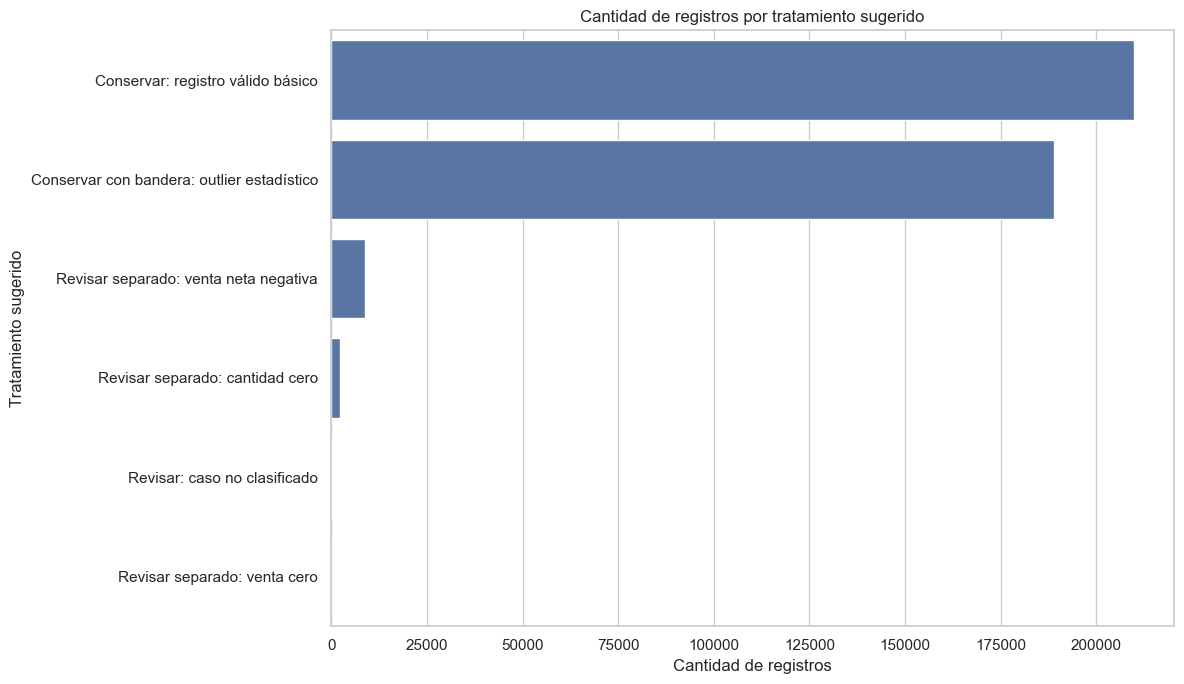

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\outliers\tratamiento_sugerido_registros.png


In [39]:
# ===============================
# Gráfico tratamiento sugerido
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=resumen_tratamiento.sort_values("filas", ascending=False),
    y="TRATAMIENTO_SUGERIDO",
    x="filas"
)

plt.title("Cantidad de registros por tratamiento sugerido")
plt.xlabel("Cantidad de registros")
plt.ylabel("Tratamiento sugerido")
plt.tight_layout()

output_fig = OUTLIERS_FIGURES_DIR / "tratamiento_sugerido_registros.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [40]:
# ===============================
# Base sugerida de registros válidos básicos
# ===============================

df_validos_basicos = df[df["REGISTRO_VALIDO_BASICO"]].copy()

resumen_comparacion_base = pd.DataFrame({
    "metrica": [
        "Filas",
        "Venta bruta",
        "Descuento",
        "Venta neta",
        "Unidades",
        "Tickets",
        "Productos",
        "PDV",
        "Categorías"
    ],
    "base_completa": [
        len(df),
        df["VENTA"].sum(),
        df["DESCUENTO"].sum(),
        df["VENTA_NETA"].sum(),
        df["CANT"].sum(),
        df["TICKET_ID"].nunique(),
        df["PLU_SAP"].nunique(),
        df["PDV"].nunique(),
        df["CATEG"].nunique()
    ],
    "base_validos_basicos": [
        len(df_validos_basicos),
        df_validos_basicos["VENTA"].sum(),
        df_validos_basicos["DESCUENTO"].sum(),
        df_validos_basicos["VENTA_NETA"].sum(),
        df_validos_basicos["CANT"].sum(),
        df_validos_basicos["TICKET_ID"].nunique(),
        df_validos_basicos["PLU_SAP"].nunique(),
        df_validos_basicos["PDV"].nunique(),
        df_validos_basicos["CATEG"].nunique()
    ]
})

resumen_comparacion_base["diferencia"] = (
    resumen_comparacion_base["base_completa"] -
    resumen_comparacion_base["base_validos_basicos"]
)

resumen_comparacion_base["diferencia_pct"] = np.where(
    resumen_comparacion_base["base_completa"] != 0,
    resumen_comparacion_base["diferencia"] / resumen_comparacion_base["base_completa"] * 100,
    np.nan
)

resumen_comparacion_base

,metrica,base_completa,base_validos_basicos,diferencia,diferencia_pct
0,Filas,"409,760.00","398,537.00","11,223.00",2.74
1,Venta bruta,"139,462,498.00","138,809,582.00","652,916.00",0.47
2,Descuento,"16,270,136.00","12,483,843.00","3,786,293.00",23.27
3,Venta neta,"123,192,362.00","126,325,739.00","-3,133,377.00",-2.54
4,Unidades,"494,973.23","483,892.06","11,081.17",2.24
5,Tickets,"276,989.00","276,260.00",729.00,0.26
6,Productos,"6,039.00","5,973.00",66.00,1.09
7,PDV,3.00,3.00,0.00,0.00
8,Categorías,7.00,7.00,0.00,0.00


In [41]:
# ===============================
# Guardar bases auxiliares
# ===============================

REGISTROS_ESPECIALES_FILE = PROCESSED_DIR / "registros_especiales.parquet"
REGISTROS_VALIDOS_FILE = PROCESSED_DIR / "ventas_validos_basicos.parquet"
DIAS_ATIPICOS_FILE = PROCESSED_DIR / "dias_atipicos.parquet"
PRODUCTOS_ATIPICOS_FILE = PROCESSED_DIR / "productos_atipicos.parquet"
TICKETS_ATIPICOS_FILE = PROCESSED_DIR / "tickets_atipicos.parquet"

df_especiales.to_parquet(REGISTROS_ESPECIALES_FILE, index=False)
df_validos_basicos.to_parquet(REGISTROS_VALIDOS_FILE, index=False)
dias_atipicos.to_parquet(DIAS_ATIPICOS_FILE, index=False)
productos[productos["OUTLIER_PRODUCTO_GENERAL"]].to_parquet(PRODUCTOS_ATIPICOS_FILE, index=False)
tickets[tickets["OUTLIER_TICKET_GENERAL"]].to_parquet(TICKETS_ATIPICOS_FILE, index=False)

print("Bases auxiliares guardadas correctamente.")
print(REGISTROS_ESPECIALES_FILE)
print(REGISTROS_VALIDOS_FILE)
print(DIAS_ATIPICOS_FILE)
print(PRODUCTOS_ATIPICOS_FILE)
print(TICKETS_ATIPICOS_FILE)

Bases auxiliares guardadas correctamente.
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\registros_especiales.parquet
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_validos_basicos.parquet
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\dias_atipicos.parquet
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\productos_atipicos.parquet
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\tickets_atipicos.parquet


In [42]:
# ===============================
# Exportar tablas del análisis de outliers
# ===============================

output_excel = TABLES_DIR / "08_outliers_y_casos_especiales.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    casos_especiales.to_excel(writer, sheet_name="casos_generales", index=False)
    especiales_pdv.to_excel(writer, sheet_name="especiales_pdv", index=False)
    especiales_categoria.to_excel(writer, sheet_name="especiales_categoria", index=False)
    resumen_outliers_linea.to_excel(writer, sheet_name="outliers_linea", index=False)
    ventas_negativas.to_excel(writer, sheet_name="ventas_negativas", index=False)
    cantidades_negativas.to_excel(writer, sheet_name="cant_negativas", index=False)
    ventas_cero.to_excel(writer, sheet_name="ventas_cero", index=False)
    descuento_mayor_venta.to_excel(writer, sheet_name="desc_mayor_venta", index=False)
    venta_neta_negativa.to_excel(writer, sheet_name="venta_neta_neg", index=False)
    venta_negativa_pdv_categoria.to_excel(writer, sheet_name="vneg_pdv_categoria", index=False)
    ventas_diarias.to_excel(writer, sheet_name="ventas_diarias", index=False)
    dias_atipicos.to_excel(writer, sheet_name="dias_atipicos", index=False)
    productos.to_excel(writer, sheet_name="productos_outliers", index=False)
    resumen_outliers_producto.to_excel(writer, sheet_name="outliers_producto", index=False)
    productos_extremos_venta.to_excel(writer, sheet_name="prod_ext_venta", index=False)
    productos_precio_extremo.to_excel(writer, sheet_name="prod_ext_precio", index=False)
    tickets.to_excel(writer, sheet_name="tickets_outliers", index=False)
    resumen_outliers_ticket.to_excel(writer, sheet_name="outliers_ticket", index=False)
    tickets_extremos_venta.to_excel(writer, sheet_name="tickets_ext_venta", index=False)
    detalle_tickets_extremos.to_excel(writer, sheet_name="detalle_tickets_ext", index=False)
    cruce_especial_outlier.to_excel(writer, sheet_name="cruce_esp_outlier", index=False)
    resumen_tratamiento.to_excel(writer, sheet_name="tratamiento", index=False)
    resumen_comparacion_base.to_excel(writer, sheet_name="comparacion_base", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\08_outliers_y_casos_especiales.xlsx


## Conclusiones del análisis de outliers y casos especiales

El análisis de outliers y casos especiales permite entender que no todos los registros atípicos deben tratarse de la misma manera.

Las principales conclusiones son:

1. Existen registros con comportamientos especiales como ventas negativas, cantidades negativas, ventas en cero, descuentos mayores que la venta y ventas netas negativas.

2. Estos casos no deben eliminarse automáticamente, ya que pueden representar devoluciones, ajustes, notas crédito, errores de registro o condiciones comerciales particulares.

3. Las ventas netas negativas están fuertemente relacionadas con descuentos mayores que la venta. Estos registros deben analizarse por separado antes de construir un modelo predictivo.

4. Los outliers estadísticos en ventas, cantidades, descuentos y precios unitarios pueden representar operaciones reales de alto valor, por lo que conviene conservarlos con banderas en lugar de eliminarlos directamente.

5. El análisis por PDV y categoría permite revisar si los problemas de calidad se concentran en tiendas o categorías específicas.

6. Los días atípicos pueden corresponder a eventos comerciales, cierres de mes, promociones, errores de carga o comportamientos extraordinarios de consumo.

7. Los productos y tickets atípicos deben revisarse con detalle porque pueden tener un peso importante en la venta total.

8. Para análisis descriptivos generales, se puede trabajar con la base completa, siempre interpretando los casos especiales.

9. Para modelado predictivo, se recomienda construir al menos dos escenarios:
   - Un escenario con todos los registros, conservando banderas de casos especiales.
   - Un escenario con registros válidos básicos, excluyendo casos negativos o inconsistentes.

10. Las variables de calidad y outliers pueden ser útiles como variables auxiliares para explicar comportamientos inusuales en las ventas.